# 03 — Model Predictive Control: Receding Horizon, Feasibility, and Stability

## Why solving a finite-horizon optimization problem repeatedly can become a stabilizing feedback law

A finite-horizon optimal-control problem computes a sequence

$$
u_0^\star,\ldots,u_{N-1}^\star.
$$

Model Predictive Control changes the interpretation of that sequence:

1. solve the finite-horizon problem at the current state;
2. apply **only the first input**;
3. measure the new state;
4. shift the prediction horizon;
5. solve again.

This creates a feedback law through repeated optimization.

But an important question immediately appears:

> If the optimization problem is feasible now, why should it still be feasible after applying the
> first input?

And an even deeper question is:

> Even if it remains feasible forever, why should the closed-loop state converge to the desired
> equilibrium?

These are the two central topics of this notebook:

$$
\boxed{\text{recursive feasibility}}
\qquad\text{and}\qquad
\boxed{\text{closed-loop stability}}.
$$

The main mechanism is the careful design of **terminal ingredients**:

$$
\boxed{
\text{terminal constraint}
+
\text{terminal cost}.
}
$$


## Learning objectives

After completing this notebook, you should be able to:

1. write the receding-horizon MPC algorithm using prediction notation $x_{k|t}$ and $u_{k|t}$;
2. distinguish an open-loop finite-horizon solution from the MPC closed-loop law;
3. distinguish:
   - feasibility,
   - recursive feasibility,
   - constraint satisfaction,
   - stability,
   - region of attraction;
4. explain why a finite prediction horizon can lose stability;
5. prove recursive feasibility for the zero terminal constraint $x_N=0$;
6. prove decrease of the optimal value function in that special case, and state the bounds
   needed to conclude asymptotic stability;
7. state the general terminal-set/terminal-cost assumptions;
8. reproduce the shifted-sequence proof with a local terminal controller;
9. derive the LQR terminal cost from the discrete algebraic Riccati equation;
10. construct an admissible LQR terminal invariant set;
11. verify the terminal Lyapunov decrease numerically;
12. compare zero-terminal and invariant-terminal feasible regions;
13. explain how the horizon length affects the feasible/attraction region;
14. verify the MPC value-function decrease along a closed-loop simulation.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

from advanced_mpc_lmpc.linear import dlqr
from advanced_mpc_lmpc.mpc import LinearMPC
from advanced_mpc_lmpc.polytopes import (
    HPolytope,
    closed_loop_admissible_set_scalar_input,
    maximal_invariant,
    maximal_control_invariant,
    n_step_controllable_sets,
)
from advanced_mpc_lmpc.plotting import plot_polytope

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
})


## Table of Contents

- **[Part I — From finite-horizon optimal control to feedback](#part-1)** — I.1 The ideal infinite-horizon problem · I.2 Finite-horizon problem solved at real time $t$ · I.3 The receding-horizon law · I.4 Predicted trajectory versus closed-loop trajectory
- **[Part II — What exactly must be guaranteed?](#part-2)** — II.1 Feasibility · II.2 Recursive feasibility · II.3 Constraint satisfaction · II.4 Stability and region of attraction
- **[Part III — Why a short horizon can fail](#part-3)** — III.1 One-step MPC without a terminal cost · III.2 Add the infinite-horizon LQR terminal cost
- **[Part IV — The zero terminal constraint](#part-4)** — IV.1 MPC with $x_N=0$ · IV.2 Recursive-feasibility proof for $x_N=0$ · IV.3 Stability proof for the zero terminal constraint
- **[Part V — Horizon length and the feasible region](#part-5)** — V.1 Double-integrator example · V.2 Interpretation
- **[Part VI — General terminal sets](#part-6)** — VI.1 Why replace $x_N=0$ by $x_N\in\mathcal X_f$? · VI.2 General terminal-set assumptions · VI.3 Recursive feasibility with a general terminal set · VI.4 Optimal-value decrease with the terminal controller · VI.5 The conceptual role of the terminal ingredients
- **[Part VII — Linear-quadratic terminal ingredients](#part-7)** — VII.1 Quadratic stage and terminal costs · VII.2 DARE and feedback-sign convention · VII.3 The LQR terminal-cost identity · VII.4 Input constraints restrict the LQR terminal region · VII.5 Verify the terminal-set assumptions numerically
- **[Part VIII — Zero terminal point versus invariant terminal region](#part-8)** — VIII.1 Same horizon, different terminal ingredients · VIII.2 A state that exposes the difference
- **[Part IX — Receding-horizon simulation with stabilizing terminal ingredients](#part-9)** — IX.1 MPC controller · IX.2 Use the **full** theoretical finite-horizon cost · IX.3 Check the Lyapunov decrease inequality numerically · IX.4 Why the equality is nearly exact in this example
- **[Part X — What the terminal theorem does and does not say](#part-10)** — X.1 It is a sufficient design mechanism · X.2 Zero terminal set is simple but conservative · X.3 Increasing the horizon is another lever · X.4 Nominal versus robust guarantees · X.5 Nonlinear extension
- **[Part XI — Common conceptual pitfalls](#part-11)** — XI.1 Pitfall: feasible now means recursively feasible · XI.2 Pitfall: a long horizon automatically proves stability · XI.3 Pitfall: $P$ from the DARE is enough by itself · XI.4 Pitfall: the terminal set must be the origin · XI.5 Pitfall: continuous-time and discrete-time stability conditions are interchangeable · XI.6 Pitfall: the solver objective is automatically the Lyapunov value
- **[Part XII — Check your understanding](#part-12)**
- **[Part XIII — Exercises](#part-13)**
- **[Part XIV — Scope and references](#part-14)**


<a id="part-1"></a>
# Part I — From finite-horizon optimal control to feedback

## I.1 The ideal infinite-horizon problem

For

$$
x_{k+1}=Ax_k+Bu_k,
$$

the ideal constrained control objective can be written as

$$
J_\infty^\star(x(0))
=
\min_{\{u_k\}_{k=0}^{\infty}}
\sum_{k=0}^{\infty}q(x_k,u_k)
$$

subject to the dynamics and constraints

$$
x_k\in\mathcal X,
\qquad
u_k\in\mathcal U.
$$

The stage cost $q(x,u)$ expresses the cost of being in state $x$ and applying input $u$.

The difficulty is immediate: the optimization contains an infinite number of future decisions.

MPC replaces this impossible online problem by a finite-horizon approximation and repeats that
approximation in feedback.


## I.2 Finite-horizon problem solved at real time $t$

At time $t$, denote predicted quantities by

$$
x_{k|t},
\qquad
u_{k|t}.
$$

Here:

- the second index $t$ is the real time at which the prediction is made;
- the first index $k$ identifies the future time represented by that prediction.

The current measured state initializes the prediction:

$$
x_{t|t}=x(t).
$$

A horizon-$N$ problem is

$$
\begin{aligned}
J_t^\star(x(t))
=
\min_{\{u_{k|t}\}}
\quad&
p(x_{t+N|t})
+
\sum_{k=t}^{t+N-1}
q(x_{k|t},u_{k|t})
\\
\text{s.t.}\quad&
x_{k+1|t}=Ax_{k|t}+Bu_{k|t},
\\
&
x_{k|t}\in\mathcal X,
\qquad
u_{k|t}\in\mathcal U,
\\
&
x_{t+N|t}\in\mathcal X_f,
\\
&
x_{t|t}=x(t).
\end{aligned}
$$


## I.3 The receding-horizon law

Let

$$
U_{t\to t+N|t}^\star
=
\left\{
u_{t|t}^\star,
u_{t+1|t}^\star,
\ldots,
u_{t+N-1|t}^\star
\right\}.
$$

MPC applies only

$$
\boxed{
u(t)=u_{t|t}^\star.
}
$$

The real system evolves to

$$
x(t+1)=Ax(t)+Bu(t).
$$

At time $t+1$, the old prediction is discarded as an optimization plan and a **new problem is
solved from the new state**.

Therefore the MPC feedback law is

$$
u(t)=\kappa_N(x(t)),
$$

where $\kappa_N(\cdot)$ is defined implicitly by an optimization problem.

For a time-invariant model, cost, and constraint sets, this map is itself time invariant.


## I.4 Predicted trajectory versus closed-loop trajectory

This distinction is fundamental.

At time $t$, the optimizer predicts

$$
x_{t|t},
x_{t+1|t},
\ldots,
x_{t+N|t}.
$$

At time $t+1$, it predicts a new sequence

$$
x_{t+1|t+1},
x_{t+2|t+1},
\ldots.
$$

Only the first transition of each predicted trajectory is actually executed before replanning.

So MPC is **not** “optimize once and execute the complete sequence.”

It is

$$
\boxed{
\text{optimize}
\rightarrow
\text{apply one action}
\rightarrow
\text{measure}
\rightarrow
\text{optimize again}.
}
$$


<a id="part-2"></a>
# Part II — What exactly must be guaranteed?

## II.1 Feasibility

At state $x$, the horizon-$N$ problem is feasible if there exists at least one admissible input
sequence satisfying all predicted constraints and the terminal constraint.

Define the finite-horizon feasible set

$$
\mathcal X_N
=
\{x:\text{the MPC optimization is feasible from }x\}.
$$

This is a statement about the optimization **now**.


## II.2 Recursive feasibility

MPC is **recursively feasible** if

$$
x(t)\in\mathcal X_N
$$

implies that, after applying the MPC action,

$$
x(t+1)\in\mathcal X_N.
$$

In words:

> feasible now $\Longrightarrow$ feasible again at the next sampling instant.

If this implication holds repeatedly, the optimization never “paints itself into a corner.”

Current feasibility alone does **not** imply recursive feasibility.


## II.3 Constraint satisfaction

If the prediction model is exact, the current state is known, and the MPC problem remains
recursively feasible, then the executed first input/state pair inherits the constraints imposed
on the prediction.

This is distinct from stability:

- a trajectory may satisfy all constraints but fail to converge;
- a stable unconstrained controller may violate actuator or state limits.

Constraint satisfaction and stability are different properties.


## II.4 Stability and region of attraction

For regulation to the origin, asymptotic stability requires

$$
x(t)\to0
\qquad
\text{as}
\qquad
t\to\infty,
$$

for initial states in some neighborhood/set.

The **region of attraction** is the set of initial states from which the closed-loop trajectory
converges to the equilibrium while preserving the required properties.

For MPC designs based on stabilizing terminal ingredients, the finite-horizon feasible set becomes
a natural certified region of attraction under the theorem assumptions.


<a id="part-3"></a>
# Part III — Why a short horizon can fail

Reducing the prediction horizon can destroy stability, even when every finite-horizon problem is
solved exactly. The following scalar example is a deliberately minimal illustration of that
mechanism.

## III.1 One-step MPC without a terminal cost

Consider the unstable scalar plant

$$
x^+=ax+u,
\qquad
a=1.2.
$$

Use the stage cost

$$
q(x,u)=x^2+ru^2,
\qquad
r>0.
$$

For horizon

$$
N=1
$$

with **no terminal cost**, the optimization is

$$
\min_{u_0}
x_0^2+ru_0^2.
$$

The future state $x_1$ does not appear in the objective.

Therefore

$$
u_0^\star=0.
$$

The receding-horizon closed loop becomes

$$
x(t+1)=1.2x(t),
$$

which is unstable.

The optimizer is solving its finite-horizon problem perfectly.
The design of that finite-horizon problem is the issue.


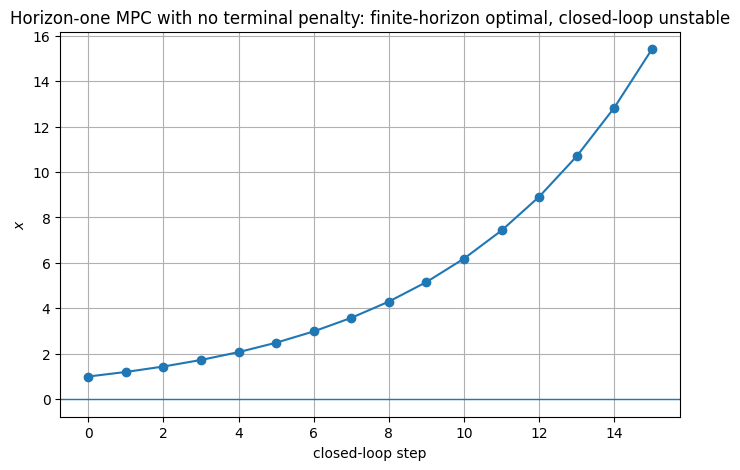

In [2]:
a = 1.2
r = 4.0

x = 1.0
xs_short = [x]
us_short = []

for _ in range(15):
    # N=1, q(x,u)=x^2+r u^2, no terminal penalty:
    # x^2 is constant w.r.t. u, so u*=0.
    u = 0.0
    us_short.append(u)
    x = a * x + u
    xs_short.append(x)

plt.figure()
plt.plot(xs_short, marker="o")
plt.axhline(0.0, linewidth=1)
plt.xlabel("closed-loop step")
plt.ylabel(r"$x$")
plt.title("Horizon-one MPC with no terminal penalty: finite-horizon optimal, closed-loop unstable")
plt.show()


## III.2 Add the infinite-horizon LQR terminal cost

Now choose

$$
p(x)=Px^2,
$$

where $P$ solves the discrete algebraic Riccati equation.

The one-step optimization becomes

$$
\min_u
x^2+ru^2+P(ax+u)^2.
$$

Differentiating with respect to $u$ gives

$$
2ru+2P(ax+u)=0,
$$

hence

$$
u^\star
=
-\frac{Pa}{r+P}x.
$$

This is exactly the scalar discrete-time LQR feedback when $P$ is the Riccati solution.

A carefully chosen terminal cost can therefore inject information about the infinite future into
a short finite horizon.


P = 3.8098971171636027
K = 0.5853952327424176
closed-loop eigenvalue = 0.6146047672575824


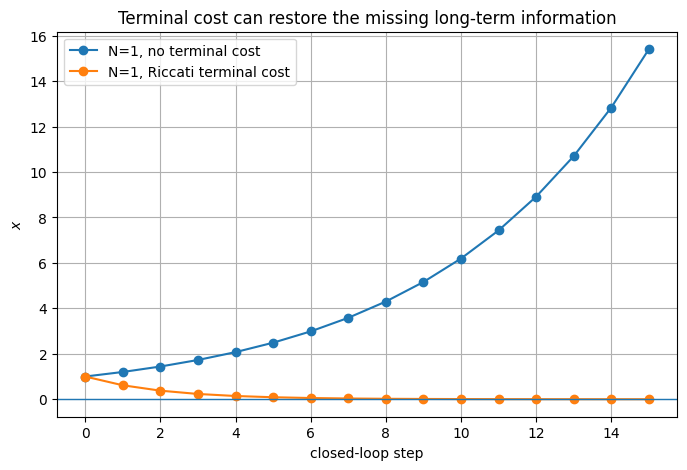

In [3]:
A_scalar = np.array([[a]])
B_scalar = np.array([[1.0]])
Q_scalar = np.array([[1.0]])
R_scalar = np.array([[r]])

K_scalar, P_scalar, eig_scalar = dlqr(
    A_scalar, B_scalar, Q_scalar, R_scalar
)

print("P =", P_scalar.item())
print("K =", K_scalar.item())
print("closed-loop eigenvalue =", eig_scalar.item())

x = 1.0
xs_terminal_cost = [x]
us_terminal_cost = []

for _ in range(15):
    u = float((-K_scalar @ np.array([x])).item())
    us_terminal_cost.append(u)
    x = a * x + u
    xs_terminal_cost.append(x)

plt.figure()
plt.plot(xs_short, marker="o", label="N=1, no terminal cost")
plt.plot(xs_terminal_cost, marker="o", label="N=1, Riccati terminal cost")
plt.axhline(0.0, linewidth=1)
plt.xlabel("closed-loop step")
plt.ylabel(r"$x$")
plt.title("Terminal cost can restore the missing long-term information")
plt.legend()
plt.show()


<a id="part-4"></a>
# Part IV — The zero terminal constraint

## IV.1 MPC with $x_N=0$

Consider

$$
\begin{aligned}
J_N^\star(x)
=
\min_{U}
\quad&
\sum_{k=0}^{N-1}q(x_k,u_k)
\\
\text{s.t.}\quad&
x_{k+1}=Ax_k+Bu_k,
\\
&
x_k\in\mathcal X,
\quad
u_k\in\mathcal U,
\\
&
\boxed{x_N=0},
\\
&
x_0=x.
\end{aligned}
$$

This is the simplest stabilizing terminal constraint.

Its advantage is theoretical clarity.
Its disadvantage is that reaching exactly zero within $N$ steps can make the feasible set small.


## IV.2 Recursive-feasibility proof for $x_N=0$

Assume the optimization at state $x(0)$ is feasible and produces

$$
U^\star
=
\{u_0^\star,u_1^\star,\ldots,u_{N-1}^\star\}
$$

with predicted states

$$
x_0=x(0),x_1,\ldots,x_N=0.
$$

Apply the first optimal input:

$$
u(0)=u_0^\star.
$$

Under the nominal model,

$$
x(1)=x_1.
$$

At the next time instant, consider the **shifted candidate**

$$
\tilde U
=
\{
u_1^\star,
u_2^\star,
\ldots,
u_{N-1}^\star,
0
\}.
$$

The old prediction already guarantees that all shifted intermediate states satisfy their
constraints.

Because

$$
x_N=0
$$

and the equilibrium satisfies

$$
A0+B0=0,
$$

the appended zero input keeps the new terminal state at zero.

Hence the shifted sequence is feasible at $x(1)$.

Therefore

$$
\boxed{
x(0)\in\mathcal X_N
\Longrightarrow
x(1)\in\mathcal X_N.
}
$$


## IV.3 Stability proof for the zero terminal constraint

Let the optimal value at $x_0$ be

$$
J_N^\star(x_0)
=
\sum_{k=0}^{N-1}
q(x_k,u_k^\star).
$$

At the next state $x_1$, the shifted sequence is feasible, so the new optimum cannot cost more
than that candidate:

$$
J_N^\star(x_1)
\le
\sum_{k=1}^{N-1}
q(x_k,u_k^\star)
+
q(0,0).
$$

Assuming

$$
q(0,0)=0,
$$

we obtain

$$
\boxed{
J_N^\star(x_1)
-
J_N^\star(x_0)
\le
-q(x_0,u_0^\star).
}
$$

If the stage cost is positive definite with respect to the origin, then the optimal value decreases
strictly away from the equilibrium.

This makes $J_N^\star$ a Lyapunov-function candidate. Decrease alone, however, does not prove
asymptotic stability: $J_N^\star$ must also be bounded from below and from above by functions of
$\lVert x\rVert$.

### From value decrease to asymptotic stability

A function $\alpha:[0,\infty)\to[0,\infty)$ is of class $\mathcal K$ if it is continuous, strictly
increasing and satisfies $\alpha(0)=0$. Write the closed loop as $x^+=Ax+B\kappa_N(x)$ and suppose
there are class-$\mathcal K$ functions $\alpha_1,\alpha_2$ and a radius $r>0$ such that:

1. **Lower bound.** $q(x,u)\ge\alpha_1(\lVert x\rVert)$ for all admissible $(x,u)$. Since
   $J_N^\star(x)\ge q(x,u_0^\star)$, this gives $J_N^\star(x)\ge\alpha_1(\lVert x\rVert)$ on $\mathcal X_N$.
2. **Upper bound near the origin.** $J_N^\star(x)\le\alpha_2(\lVert x\rVert)$ for all $x\in\mathcal X_N$
   with $\lVert x\rVert\le r$. Because $J_N^\star\ge0$ and $J_N^\star(0)=0$, this is equivalent to
   $J_N^\star$ being continuous at the origin.
3. **Decrease.** $J_N^\star(x^+)-J_N^\star(x)\le-q(x,\kappa_N(x))\le-\alpha_1(\lVert x\rVert)$ for all
   $x\in\mathcal X_N$: the boxed inequality above.

Then the origin is asymptotically stable for the closed loop, with region of attraction
$\mathcal X_N$ (positively invariant by IV.2). If moreover $\alpha_1(s)=c_1s^2$ and
$J_N^\star(x)\le c_2\lVert x\rVert^2$ on $\mathcal X_N$, the origin is exponentially stable on $\mathcal X_N$:
$J_N^\star(x(t+1))\le(1-c_1/c_2)\,J_N^\star(x(t))$, hence
$\lVert x(t)\rVert\le\sqrt{c_2/c_1}\,(1-c_1/c_2)^{t/2}\lVert x(0)\rVert$. On a bounded $\mathcal X_N$, a
quadratic upper bound near the origin extends to all of $\mathcal X_N$, because $J_N^\star$ is bounded there.

The conditions do different jobs. Summing the decrease along the closed loop gives
$\sum_{t\ge0}\alpha_1(\lVert x(t)\rVert)\le J_N^\star(x(0))<\infty$, so $x(t)\to0$ from every
$x(0)\in\mathcal X_N$. The upper bound adds Lyapunov stability, that is, small initial states stay
small: for $\lVert x(0)\rVert\le r$ and all $t$,
$\alpha_1(\lVert x(t)\rVert)\le J_N^\star(x(t))\le J_N^\star(x(0))\le\alpha_2(\lVert x(0)\rVert)$, and the
right-hand side vanishes as $x(0)\to0$.

### Why the upper bound needs an extra assumption when $x_N=0$

The lower bound comes from the stage cost and the decrease from the shifted sequence, but nothing so
far gives the upper bound. With $x_N=0$, the only admissible plans are those that reach the origin
exactly in $N$ steps, and for some systems (typically nonlinear ones) this forces large inputs, and
hence a large cost, even from very small states. Then $J_N^\star(x)$ does not tend to $0$ as $x\to0$: $J_N^\star$ is
discontinuous at the origin and no class-$\mathcal K$ upper bound exists. An extra assumption is
needed, for example **local controllability with small inputs**: every $x$ with $\lVert x\rVert\le r$
can be steered to the origin in $N$ admissible steps with inputs $\lVert u_k\rVert\le\gamma(\lVert x\rVert)$,
for some class-$\mathcal K$ function $\gamma$. The cost of that plan bounds $J_N^\star(x)$ by a
class-$\mathcal K$ function of $\lVert x\rVert$.

For the linear model used here, the assumption holds when $(A,B)$ is controllable, $N\ge n$, and the
origin lies in the interior of $\mathcal X$ and $\mathcal U$. The minimum-norm plan
$U=-\mathcal C_N^{\dagger}A^Nx$, with $\mathcal C_N=\begin{bmatrix}A^{N-1}B&\cdots&AB&B\end{bmatrix}$,
reaches $x_N=0$ and is linear in $x$, so it is admissible for small $x$; with a quadratic stage cost it
gives $J_N^\star(x)\le c\lVert x\rVert^2$ near the origin.

### A terminal set provides the upper bound

Now consider the terminal-set formulation of Part VI, with a terminal set $\mathcal X_f$ that contains
the origin in its interior, a local controller $v$ and a terminal cost $p$. For $x\in\mathcal X_f$,
applying $v$ for $N$ steps is a feasible plan, and summing the terminal decrease along it bounds its
cost by $p(x)$. Hence the optimal value of that problem satisfies

$$
J_N^\star(x)\le p(x)\qquad\text{for all }x\in\mathcal X_f.
$$

Any terminal cost with $p(x)\le\alpha_2(\lVert x\rVert)$, such as the quadratic $p(x)=x^\top Px$ of
Part VII, therefore gives the upper bound on a ball around the origin inside $\mathcal X_f$, with no
extra controllability assumption. This is one reason the terminal-set design of Part VI is preferred
to $x_N=0$.


<a id="part-5"></a>
# Part V — Horizon length and the feasible region

## V.1 Double-integrator example

We now use a constrained double integrator:

$$
x^+
=
\begin{bmatrix}
1&1\\
0&1
\end{bmatrix}x
+
\begin{bmatrix}
0\\1
\end{bmatrix}u,
$$

with

$$
-5\le x_i\le5,
$$

and

$$
-0.5\le u\le0.5.
$$

We compare the set of states that can reach

$$
x_N=0
$$

for different horizons.

Geometrically, this is precisely a finite-step controllability calculation.


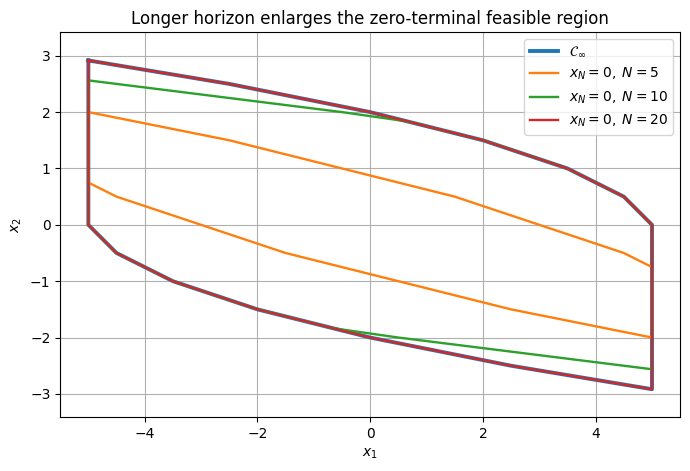

In [4]:
A = np.array([
    [1.0, 1.0],
    [0.0, 1.0],
])

B = np.array([
    [0.0],
    [1.0],
])

X = HPolytope.box(
    [-5.0, -5.0],
    [ 5.0,  5.0],
)

umin, umax = -0.5, 0.5

# Exact singleton {0}: +x<=0 and -x<=0.
zero_terminal = HPolytope(
    np.vstack([np.eye(2), -np.eye(2)]),
    np.zeros(4),
)

zero_sets = {}
for N in [5, 10, 20]:
    zero_sets[N] = n_step_controllable_sets(
        A, B, X, zero_terminal,
        umin, umax, N
    )[-1]

Cinf, _ = maximal_control_invariant(
    A, B, X,
    umin, umax
)

plt.figure()
ax = plt.gca()
plot_polytope(ax, Cinf, linewidth=2.8,
              label=r"$\mathcal{C}_\infty$")
for N, S_N in zero_sets.items():
    plot_polytope(ax, S_N, linewidth=1.7,
                  label=rf"$x_N=0,\;N={N}$")

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Longer horizon enlarges the zero-terminal feasible region")
plt.axis("equal")
plt.legend()
plt.show()


In [5]:
def polygon_area(P):
    V = P.vertices_2d()
    if len(V) < 3:
        return 0.0
    x = V[:, 0]
    y = V[:, 1]
    return 0.5 * abs(
        np.dot(x, np.roll(y, -1))
        - np.dot(y, np.roll(x, -1))
    )

area_Cinf = polygon_area(Cinf)

print(f"area(C_inf) = {area_Cinf:.4f}")
for N, S_N in zero_sets.items():
    area = polygon_area(S_N)
    print(
        f"N={N:2d}: area={area:.4f}, "
        f"fraction of C_inf={area/area_Cinf:.3f}"
    )


area(C_inf) = 37.2917
N= 5: area=16.1250, fraction of C_inf=0.432
N=10: area=34.9479, fraction of C_inf=0.937
N=20: area=37.2917, fraction of C_inf=1.000


## V.2 Interpretation

For the zero terminal condition, the horizon controls how much time the optimizer has to drive
the state exactly to the origin.

A small $N$ excludes states that are perfectly manageable over a longer time scale.

As $N$ increases, the feasible set grows toward the underlying constrained controllability
limits.

This illustrates a general point:

> the horizon can have a strong impact on the region of attraction.

The price of simply increasing $N$ is computational: more future decision variables and
constraints must be handled online.


<a id="part-6"></a>
# Part VI — General terminal sets

## VI.1 Why replace $x_N=0$ by $x_N\in\mathcal X_f$?

The exact terminal equality is conservative.

Instead, choose a terminal region

$$
\boxed{
x_N\in\mathcal X_f
}
$$

with a local controller

$$
u=v(x).
$$

The interpretation is:

> the online optimizer only has to reach a region from which a known local controller can safely
> complete the infinite tail of the task.

The terminal set enlarges the finite-horizon feasible region, while the local controller and
terminal cost provide the information needed for the proof.


## VI.2 General terminal-set assumptions

The standard terminal-set stability theorem uses three ingredients.

### Assumption 1 — positive-definite stage cost

The stage cost is positive away from the desired equilibrium:

$$
q(x,u)>0
$$

for non-equilibrium state/input pairs of interest, and

$$
q(0,0)=0.
$$

For the stability conclusion, this positivity is used in the quantitative form
$q(x,u)\ge\alpha_1(\lVert x\rVert)$ with $\alpha_1$ of class $\mathcal K$ (see IV.3). For
$q(x,u)=x^\top Qx+u^\top Ru$ with $Q\succ0$, it holds with $\alpha_1(s)=\lambda_{\min}(Q)s^2$.

### Assumption 2 — terminal invariance and admissibility

There exists a local terminal control law $v(x)$ such that for all

$$
x\in\mathcal X_f,
$$

we have

$$
v(x)\in\mathcal U,
$$

and

$$
Ax+Bv(x)\in\mathcal X_f.
$$

Also,

$$
\mathcal X_f\subseteq\mathcal X.
$$

### Assumption 3 — terminal Lyapunov decrease

The terminal cost satisfies

$$
\boxed{
p(Ax+Bv(x))-p(x)
\le
-q(x,v(x))
}
$$

for all $x\in\mathcal X_f$.

These assumptions mimic the missing infinite-horizon tail.


## VI.3 Recursive feasibility with a general terminal set

Suppose the optimal sequence at $x_0$ is

$$
\{
u_0^\star,
u_1^\star,
\ldots,
u_{N-1}^\star
\},
$$

and

$$
x_N\in\mathcal X_f.
$$

After applying $u_0^\star$, use the shifted candidate

$$
\boxed{
\tilde U
=
\{
u_1^\star,
\ldots,
u_{N-1}^\star,
v(x_N)
\}.
}
$$

Because the old intermediate predictions were feasible, the shifted part remains admissible.

Because $\mathcal X_f$ is invariant under $v$,

$$
x_{N+1}
=
Ax_N+Bv(x_N)
\in\mathcal X_f.
$$

Therefore the shifted candidate is feasible at the next state.

This proves recursive feasibility.


## VI.4 Optimal-value decrease with the terminal controller

At $x_0$,

$$
J_N^\star(x_0)
=
\sum_{i=0}^{N-1}
q(x_i,u_i^\star)
+
p(x_N).
$$

At $x_1$, the shifted candidate gives

$$
J_N^\star(x_1)
\le
\sum_{i=1}^{N-1}
q(x_i,u_i^\star)
+
q(x_N,v(x_N))
+
p(x_{N+1}).
$$

Subtract the old optimal value:

$$
\begin{aligned}
J_N^\star(x_1)-J_N^\star(x_0)
\le{}&
-q(x_0,u_0^\star)
\\
&+
q(x_N,v(x_N))
+
p(x_{N+1})-p(x_N).
\end{aligned}
$$

The terminal decrease assumption gives

$$
q(x_N,v(x_N))
+
p(x_{N+1})-p(x_N)
\le0.
$$

Therefore

$$
\boxed{
J_N^\star(x_1)-J_N^\star(x_0)
\le
-q(x_0,u_0^\star).
}
$$

The same fundamental decrease inequality reappears.

The other two conditions of IV.3 hold as well. The lower bound is Assumption 1 in its quantitative
form, and the upper bound is $J_N^\star(x)\le p(x)$ on $\mathcal X_f$ (end of IV.3), valid when
$\mathcal X_f$ contains the origin in its interior and $p(x)\le\alpha_2(\lVert x\rVert)$ there. Under
Assumptions 1–3 and this condition, the origin is asymptotically stable for the MPC closed loop, with
region of attraction $\mathcal X_N$. In the linear-quadratic design of Part VII,
$q(x,u)\ge\lambda_{\min}(Q)\lVert x\rVert^2$ and $p(x)\le\lambda_{\max}(P)\lVert x\rVert^2$, so the
bounds are quadratic and the stability is exponential on the bounded set $\mathcal X_N$.


## VI.5 The conceptual role of the terminal ingredients

The proof reveals why the two terminal ingredients have different jobs.

### Terminal set

It gives a **feasible tail**:

$$
x_N\in\mathcal X_f
\quad\Longrightarrow\quad
v(x_N)
\text{ can continue admissibly}.
$$

### Terminal cost

It gives a **cost bound on that tail**:

$$
p(x^+)-p(x)
\le
-q(x,v(x)).
$$

So:

$$
\boxed{
\text{terminal set}
\Rightarrow
\text{recursive-feasibility mechanism}
}
$$

and

$$
\boxed{
\text{terminal cost}
\Rightarrow
\text{Lyapunov-decrease mechanism}.
}
$$


<a id="part-7"></a>
# Part VII — Linear-quadratic terminal ingredients

## VII.1 Quadratic stage and terminal costs

For the linear system, take

$$
q(x,u)
=
x^\top Qx+u^\top Ru,
$$

with

$$
Q\succ0,
\qquad
R\succ0.
$$

Choose the terminal cost

$$
\boxed{
p(x)=x^\top Px,
}
$$

where $P$ is the infinite-horizon discrete-time LQR Riccati solution.


## VII.2 DARE and feedback-sign convention

The repository uses

$$
\boxed{
u=-Kx.
}
$$

Many texts write the local law as

$$
v=F_\infty x.
$$

These are the same convention if

$$
F_\infty=-K.
$$

The discrete algebraic Riccati equation is

$$
P
=
A^\top PA
-
A^\top PB
(R+B^\top PB)^{-1}
B^\top PA
+
Q,
$$

and

$$
\boxed{
K
=
(R+B^\top PB)^{-1}B^\top PA.
}
$$

Hence

$$
A_{\mathrm{cl}}
=
A-BK.
$$

For discrete-time asymptotic stability we require

$$
\rho(A_{\mathrm{cl}})<1.
$$


In [6]:
Q = np.eye(2)
R = np.array([[10.0]])

K, P, eig_cl = dlqr(A, B, Q, R)
Acl = A - B @ K

print("K =")
print(K)
print("\nP =")
print(P)
print("\nclosed-loop eigenvalues =", eig_cl)
print("spectral radius =", np.max(np.abs(eig_cl)))


K =
[[0.205395 0.783524]]

P =
[[ 3.814714  4.868665]
 [ 4.868665 13.703901]]

closed-loop eigenvalues = [0.608238+0.227855j 0.608238-0.227855j]
spectral radius = 0.6495163430137743


## VII.3 The LQR terminal-cost identity

Under

$$
u=-Kx,
$$

the next state is

$$
x^+=(A-BK)x.
$$

With

$$
p(x)=x^\top Px,
$$

we have

$$
p(x^+)-p(x)
=
x^\top
\left[
(A-BK)^\top P(A-BK)-P
\right]
x.
$$

The DARE implies

$$
\boxed{
(A-BK)^\top P(A-BK)-P
=
-\left(Q+K^\top RK\right).
}
$$

Therefore

$$
\boxed{
p(x^+)-p(x)
=
-\left(
x^\top Qx
+
(-Kx)^\top R(-Kx)
\right)
=
-q(x,-Kx).
}
$$

So the terminal cost satisfies the required Lyapunov decrease **with equality** for the nominal
LQR closed loop.


In [7]:
dare_identity_residual = (
    Acl.T @ P @ Acl
    - P
    + Q
    + K.T @ R @ K
)

print("DARE terminal-decrease residual:")
print(dare_identity_residual)
print("infinity norm =", np.linalg.norm(dare_identity_residual, ord=np.inf))


DARE terminal-decrease residual:
[[0. 0.]
 [0. 0.]]
infinity norm = 4.440892098500626e-14


## VII.4 Input constraints restrict the LQR terminal region

The LQR law itself does not automatically respect actuator bounds.

We require

$$
-0.5
\le
-Kx
\le
0.5.
$$

Define

$$
\mathcal X_K
=
\left\{
x\in\mathcal X:
-0.5\le-Kx\le0.5
\right\}.
$$

We then compute the maximal positively invariant set for

$$
x^+=(A-BK)x
$$

inside $\mathcal X_K$.

That set becomes the terminal set

$$
\boxed{
\mathcal X_f.
}
$$


terminal-set fixed-point iterations: 2
terminal-set vertices:
[[-5.        1.926127]
 [-5.        0.672571]
 [ 4.84169  -1.907357]
 [ 5.       -1.926127]
 [ 5.       -0.672571]
 [-4.84169   1.907357]]


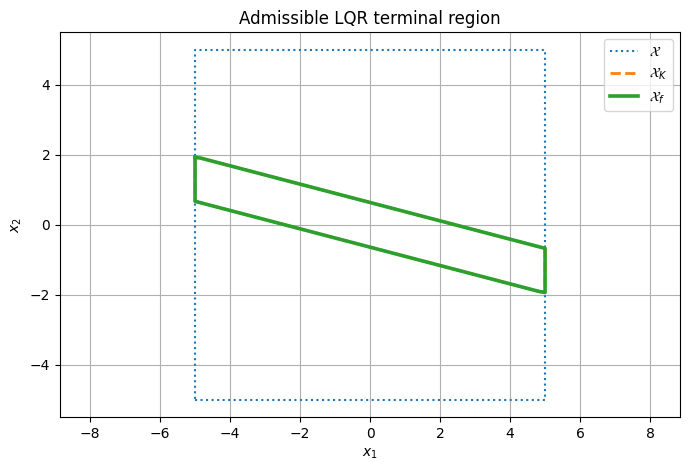

In [8]:
XK = closed_loop_admissible_set_scalar_input(
    X, K,
    umin, umax
)

Xf, Xf_history = maximal_invariant(
    Acl, XK
)

print("terminal-set fixed-point iterations:",
      len(Xf_history) - 1)
print("terminal-set vertices:")
print(Xf.vertices_2d())

plt.figure()
ax = plt.gca()
plot_polytope(ax, X, linestyle=":", label=r"$\mathcal{X}$")
plot_polytope(ax, XK, linestyle="--", linewidth=2,
              label=r"$\mathcal{X}_K$")
plot_polytope(ax, Xf, linewidth=2.6,
              label=r"$\mathcal{X}_f$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Admissible LQR terminal region")
plt.axis("equal")
plt.legend()
plt.show()


## VII.5 Verify the terminal-set assumptions numerically

For every vertex $v$ of $\mathcal X_f$, we check:

1. $v\in\mathcal X$;
2. $u=-Kv$ satisfies the input bounds;
3. $A_{\mathrm{cl}}v\in\mathcal X_f$.

For a convex polytope and linear maps, checking vertices is a useful computational diagnostic for
these linear inequalities.

We also evaluate the terminal decrease identity.


In [9]:
terminal_checks = []

for v in Xf.vertices_2d():
    u = float((-K @ v).item())
    v_next = Acl @ v

    p_now = float(v @ P @ v)
    p_next = float(v_next @ P @ v_next)
    q_local = float(v @ Q @ v + np.array([u]) @ R @ np.array([u]))

    terminal_checks.append([
        X.contains(v),
        u,
        Xf.contains(v_next, tol=1e-7),
        p_next - p_now + q_local,
    ])

terminal_checks = np.asarray(terminal_checks, dtype=float)

print("columns: [state admissible, local input, next in Xf, Lyapunov residual]")
print(terminal_checks)
print("\nmax |terminal decrease residual| =",
      np.max(np.abs(terminal_checks[:, 3])))


columns: [state admissible, local input, next in Xf, Lyapunov residual]
[[ 1.       -0.482191  1.        0.      ]
 [ 1.        0.5       1.       -0.      ]
 [ 1.        0.5       1.        0.      ]
 [ 1.        0.482191  1.        0.      ]
 [ 1.       -0.5       1.       -0.      ]
 [ 1.       -0.5       1.        0.      ]]

max |terminal decrease residual| = 2.842170943040401e-14


<a id="part-8"></a>
# Part VIII — Zero terminal point versus invariant terminal region

## VIII.1 Same horizon, different terminal ingredients

For the same online horizon $N=5$, compare:

### Design A

$$
x_N=0.
$$

### Design B

$$
x_N\in\mathcal X_f,
$$

with LQR terminal cost

$$
p(x_N)=x_N^\top Px_N.
$$

The second design allows the online optimizer to stop at any state in the certified terminal
region because the local LQR law can safely take over from there.


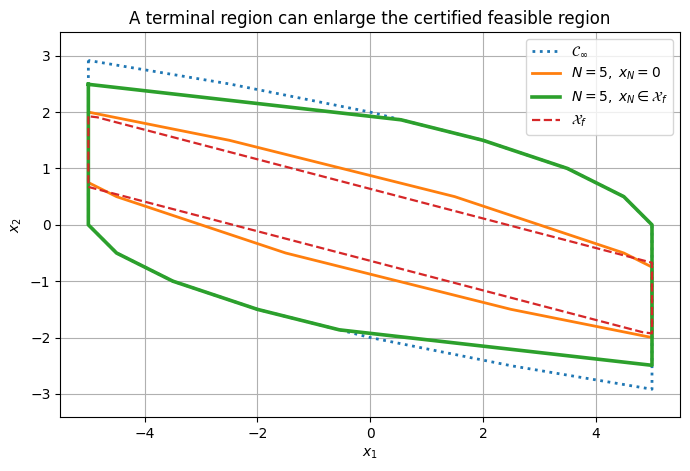

area zero-terminal N=5     : 16.125
area invariant-terminal N=5: 34.548490411584815
area maximal control invariant: 37.291666666750004


In [10]:
N_compare = 5

zero_N5 = n_step_controllable_sets(
    A, B, X, zero_terminal,
    umin, umax, N_compare
)[-1]

terminal_N5 = n_step_controllable_sets(
    A, B, X, Xf,
    umin, umax, N_compare
)[-1]

plt.figure()
ax = plt.gca()
plot_polytope(ax, Cinf, linestyle=":", linewidth=2,
              label=r"$\mathcal{C}_\infty$")
plot_polytope(ax, zero_N5, linewidth=2,
              label=r"$N=5,\;x_N=0$")
plot_polytope(ax, terminal_N5, linewidth=2.6,
              label=r"$N=5,\;x_N\in\mathcal{X}_f$")
plot_polytope(ax, Xf, linestyle="--", linewidth=1.6,
              label=r"$\mathcal{X}_f$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("A terminal region can enlarge the certified feasible region")
plt.axis("equal")
plt.legend()
plt.show()

print("area zero-terminal N=5     :", polygon_area(zero_N5))
print("area invariant-terminal N=5:", polygon_area(terminal_N5))
print("area maximal control invariant:", polygon_area(Cinf))


## VIII.2 A state that exposes the difference

Consider

$$
x_0=
\begin{bmatrix}
4.5\\
0.5
\end{bmatrix}.
$$

For the chosen horizon:

- it is **not** feasible for the exact-zero terminal requirement;
- it **is** feasible when the terminal condition is $x_N\in\mathcal X_f$.

The terminal region reduces the burden placed on the finite online horizon.


In [11]:
x_demo = np.array([4.5, 0.5])

print("x_demo in zero-terminal N=5 set? ",
      zero_N5.contains(x_demo))
print("x_demo in invariant-terminal N=5 set?",
      terminal_N5.contains(x_demo))


x_demo in zero-terminal N=5 set?  False
x_demo in invariant-terminal N=5 set? True


<a id="part-9"></a>
# Part IX — Receding-horizon simulation with stabilizing terminal ingredients

## IX.1 MPC controller

We now solve at every time step

$$
\begin{aligned}
\min\quad&
x_N^\top Px_N
+
\sum_{k=0}^{N-1}
\left(
x_k^\top Qx_k+u_k^\top Ru_k
\right)
\\
\text{s.t.}\quad&
x_{k+1}=Ax_k+Bu_k,
\\
&
x_k\in\mathcal X,
\qquad
u_k\in\mathcal U,
\\
&
x_N\in\mathcal X_f.
\end{aligned}
$$

with

$$
N=5.
$$

The controller applies only the first optimized input and resolves at the next state.


In [12]:
controller = LinearMPC(
    A, B, Q, R,
    N=5,
    P=P,
    x_lower=np.array([-5.0, -5.0]),
    x_upper=np.array([5.0, 5.0]),
    u_lower=np.array([umin]),
    u_upper=np.array([umax]),
    terminal_H=Xf.H,
    terminal_h=Xf.h,
)

first_solution = controller.solve(x_demo)

print("initial optimization success:",
      first_solution.success)
print("first control:",
      first_solution.U[0])
print("predicted terminal state:",
      first_solution.X[-1])
print("terminal state in Xf?",
      Xf.contains(first_solution.X[-1], tol=1e-6))


initial optimization success: True
first control: [-0.5]
predicted terminal state: [ 2.359246 -0.965829]
terminal state in Xf? True


## IX.2 Use the **full** theoretical finite-horizon cost

The QP solver internally drops terms that are constant with respect to the decision vector.
That is legitimate for optimization, but those dropped constants matter when we want to evaluate
the Lyapunov inequality.

So, for diagnostics, we reconstruct

$$
J_N(x)
=
x_0^\top Qx_0
+
\sum_{k=1}^{N-1}x_k^\top Qx_k
+
\sum_{k=0}^{N-1}u_k^\top Ru_k
+
x_N^\top Px_N.
$$

This is the quantity appearing in the stability proof.


In [13]:
def full_quadratic_mpc_cost(x0, Xpred, Upred, Q, R, P):
    value = float(x0 @ Q @ x0)

    for x in Xpred[:-1]:
        value += float(x @ Q @ x)

    for u in Upred:
        value += float(u @ R @ u)

    value += float(Xpred[-1] @ P @ Xpred[-1])
    return value


def stage_cost(x, u, Q, R):
    return float(x @ Q @ x + u @ R @ u)


In [14]:
x = x_demo.copy()

xs = [x.copy()]
us = []
values = []
stages = []
terminal_predictions = []

for t in range(30):
    sol = controller.solve(x)

    if not sol.success:
        raise RuntimeError(
            f"MPC unexpectedly infeasible at closed-loop step {t}: {sol.message}"
        )

    J = full_quadratic_mpc_cost(
        x, sol.X, sol.U,
        Q, R, P
    )

    u = sol.U[0].copy()

    values.append(J)
    stages.append(stage_cost(x, u, Q, R))
    terminal_predictions.append(sol.X[-1].copy())
    us.append(u.copy())

    x = A @ x + B @ u
    xs.append(x.copy())

    if np.linalg.norm(x) < 1e-5:
        break

xs = np.asarray(xs)
us = np.asarray(us)
values = np.asarray(values)
stages = np.asarray(stages)
terminal_predictions = np.asarray(terminal_predictions)

print("closed-loop steps:", len(us))
print("final state:", xs[-1])
print("max |u|:", np.max(np.abs(us)))
print("all predicted terminal states in Xf?",
      all(Xf.contains(v, tol=1e-6)
          for v in terminal_predictions))


closed-loop steps: 30
final state: [-0.000049  0.000011]
max |u|: 0.4999999999999978
all predicted terminal states in Xf? True


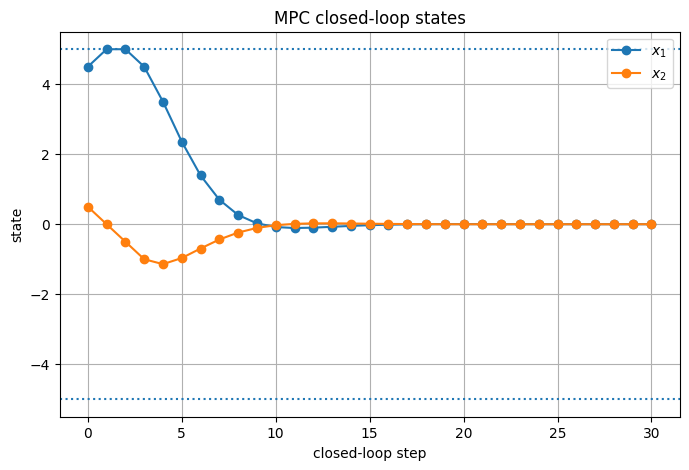

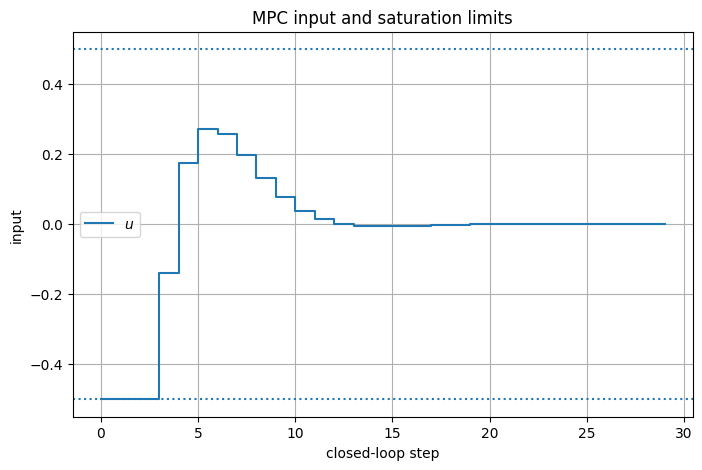

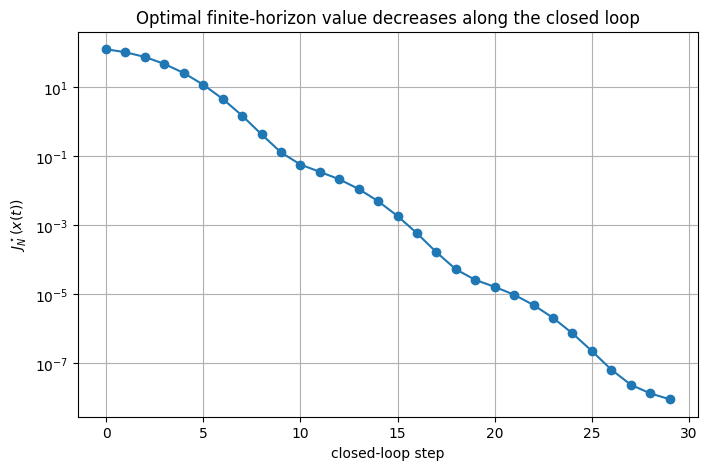

In [15]:
t_x = np.arange(len(xs))
t_u = np.arange(len(us))

plt.figure()
plt.plot(t_x, xs[:, 0], marker="o", label=r"$x_1$")
plt.plot(t_x, xs[:, 1], marker="o", label=r"$x_2$")
plt.axhline(5.0, linestyle=":")
plt.axhline(-5.0, linestyle=":")
plt.xlabel("closed-loop step")
plt.ylabel("state")
plt.title("MPC closed-loop states")
plt.legend()
plt.show()

plt.figure()
plt.step(t_u, us[:, 0], where="post", label=r"$u$")
plt.axhline(umax, linestyle=":")
plt.axhline(umin, linestyle=":")
plt.xlabel("closed-loop step")
plt.ylabel("input")
plt.title("MPC input and saturation limits")
plt.legend()
plt.show()

plt.figure()
plt.semilogy(np.maximum(values, 1e-14), marker="o")
plt.xlabel("closed-loop step")
plt.ylabel(r"$J_N^\star(x(t))$")
plt.title("Optimal finite-horizon value decreases along the closed loop")
plt.show()


## IX.3 Check the Lyapunov decrease inequality numerically

The theorem predicts

$$
J_N^\star(x(t+1))
-
J_N^\star(x(t))
\le
-q(x(t),u(t)).
$$

Equivalently,

$$
J_N^\star(x(t+1))
-
J_N^\star(x(t))
+
q(x(t),u(t))
\le0.
$$

We evaluate that residual along the simulated trajectory.


maximum decrease residual: 1.1931717835977906e-09
minimum decrease residual: -1.2174048436008889e-09


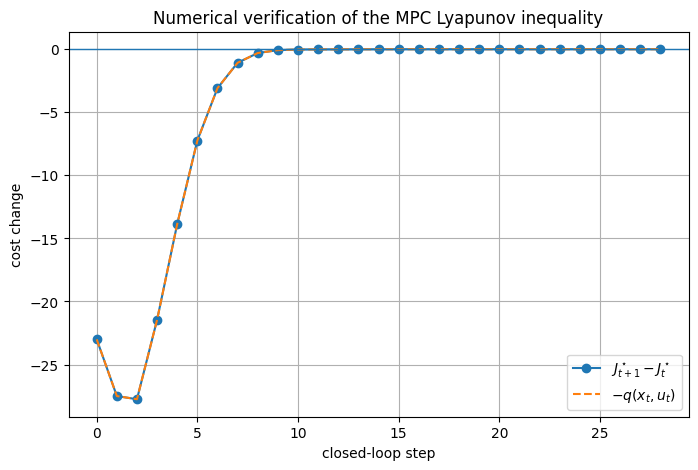

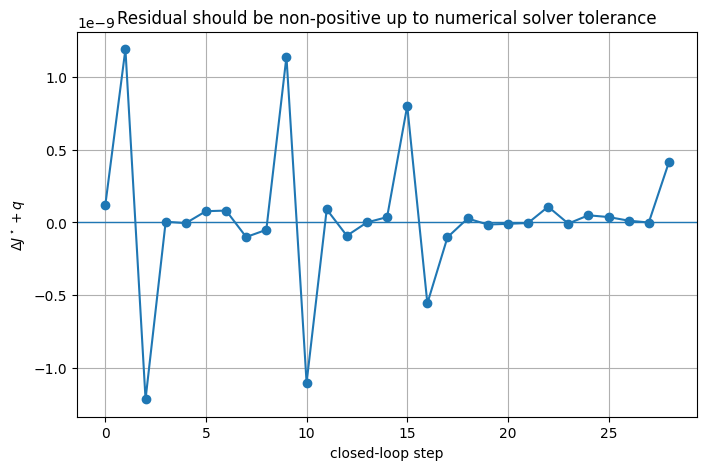

In [16]:
delta_J = np.diff(values)
decrease_residual = delta_J + stages[:-1]

print("maximum decrease residual:",
      np.max(decrease_residual))
print("minimum decrease residual:",
      np.min(decrease_residual))

plt.figure()
plt.plot(delta_J, marker="o",
         label=r"$J_{t+1}^\star-J_t^\star$")
plt.plot(-stages[:-1], "--",
         label=r"$-q(x_t,u_t)$")
plt.axhline(0.0, linewidth=1)
plt.xlabel("closed-loop step")
plt.ylabel("cost change")
plt.title("Numerical verification of the MPC Lyapunov inequality")
plt.legend()
plt.show()

plt.figure()
plt.plot(decrease_residual, marker="o")
plt.axhline(0.0, linewidth=1)
plt.xlabel("closed-loop step")
plt.ylabel(r"$\Delta J^\star + q$")
plt.title("Residual should be non-positive up to numerical solver tolerance")
plt.show()


## IX.4 Why the equality is nearly exact in this example

For this linear-quadratic design, the appended terminal controller is the infinite-horizon LQR
controller and the Riccati terminal cost satisfies

$$
p(x^+)-p(x)=-q(x,-Kx).
$$

So the terminal tail inequality is exact.

When the shifted candidate is itself optimal at the next step, the MPC value decrease can also
appear numerically very close to equality:

$$
J_N^\star(x^+)-J_N^\star(x)
\approx
-q(x,u^\star).
$$

The theorem itself requires only the inequality.


<a id="part-10"></a>
# Part X — What the terminal theorem does and does not say

## X.1 It is a sufficient design mechanism

The terminal-set/terminal-cost assumptions provide a constructive route to recursive feasibility
and stability.

They are **sufficient conditions**.

They are not a statement that every stable MPC controller must explicitly contain exactly these
terminal ingredients.

MPC without a terminal constraint may have a larger actual region of attraction, but
characterizing that region can be much harder.


## X.2 Zero terminal set is simple but conservative

Choosing

$$
\mathcal X_f=\{0\}
$$

makes the proof almost immediate.

But the finite horizon must do all the work of reaching the equilibrium exactly.

For small $N$, this can make the certified feasible region substantially smaller than necessary.


## X.3 Increasing the horizon is another lever

A longer horizon allows the online optimizer to see farther into the future.

This can enlarge the feasible/attraction region.

But it also increases online computational effort.

Terminal ingredients provide a different mechanism: encode reliable information about the tail
instead of forcing the online horizon to explicitly optimize that entire tail.


## X.4 Nominal versus robust guarantees

The recursive-feasibility proof uses the predicted successor

$$
x^+=Ax+Bu
$$

as the actual successor.

If disturbances or model errors move the real system away from the nominal prediction, the shifted
sequence may no longer be feasible.

Therefore the guarantee in this notebook is a **nominal MPC guarantee for the stated model and
constraints**.

Robust MPC requires additional constructions that explicitly account for uncertainty.


## X.5 Nonlinear extension

The same finite-horizon problem can be posed for nonlinear dynamics

$$
x_{k+1}=g(x_k,u_k),
$$

with the same terminal-set and terminal-cost structure.

The logic of the theorem is not fundamentally tied to linear dynamics:

- terminal invariance still provides the shifted feasible tail;
- terminal Lyapunov decrease still provides the cost-decrease argument;
- the bound $J_N^\star\le p$ on $\mathcal X_f$ still provides the upper bound near the origin,
  provided $\mathcal X_f$ contains the origin in its interior and $p$ is continuous with $p(0)=0$.

The difficult part is constructive:

> computing a useful nonlinear terminal invariant set and terminal Lyapunov function can be much
> harder than in the linear-quadratic case.

This notebook therefore keeps the complete numerical construction in the linear setting.


<a id="part-11"></a>
# Part XI — Common conceptual pitfalls

## XI.1 Pitfall: feasible now means recursively feasible

No.

A feasible finite-horizon trajectory can end in a state from which the next optimization has no
feasible continuation.

The terminal construction is designed specifically to prevent this.

---

## XI.2 Pitfall: a long horizon automatically proves stability

No.

A longer horizon can improve behavior and enlarge the feasible region, but “large enough” is not
itself a formal Lyapunov proof unless additional conditions are established.

---

## XI.3 Pitfall: $P$ from the DARE is enough by itself

Not under constraints.

The terminal cost may have the desired LQR decrease, while the LQR action

$$
u=-Kx
$$

violates actuator constraints.

That is why an admissible invariant terminal region is constructed.

---

## XI.4 Pitfall: the terminal set must be the origin

No.

The whole point of the general theorem is to replace the conservative equality

$$
x_N=0
$$

by a nontrivial invariant region

$$
x_N\in\mathcal X_f.
$$

---

## XI.5 Pitfall: continuous-time and discrete-time stability conditions are interchangeable

No.

For

$$
x_{k+1}=A_{\rm cl}x_k,
$$

discrete-time asymptotic stability requires

$$
\rho(A_{\rm cl})<1.
$$

It is not a condition of the form “eigenvalues $<0$,” which belongs to continuous-time reasoning.

---

## XI.6 Pitfall: the solver objective is automatically the Lyapunov value

Not necessarily in software.

QP implementations routinely drop terms that are constant with respect to the decision variables.
That does not change the optimizer, but it changes the number reported as the solver objective.

For Lyapunov diagnostics, reconstruct the complete theoretical cost.


<a id="part-12"></a>
# Part XII — Check your understanding

Try answering each question before opening the answer.

### Q1. Why is MPC a feedback controller if the optimization computes an open-loop sequence?

<details><summary>Answer</summary>

Because the complete sequence is not executed. Only its first element is applied, then the state is
measured again and a new optimization is solved. The first optimized action therefore becomes an
implicit state-feedback map.

</details>

### Q2. Define recursive feasibility.

<details><summary>Answer</summary>

If the MPC problem is feasible at the current state and the MPC action is applied, the MPC problem
must also be feasible at the next state. Repeating this property prevents future optimization
infeasibility under the nominal assumptions.

</details>

### Q3. Why can a horizon-one MPC be unstable?

<details><summary>Answer</summary>

If the cost sees only the current state and current control and contains no terminal information,
the current state term is constant with respect to the control. For an unstable plant the optimizer
may choose no corrective action because the effect on the future lies outside the horizon.

</details>

### Q4. How does the zero terminal constraint prove recursive feasibility?

<details><summary>Answer</summary>

Shift the old optimal sequence by one step and append zero. Since the old terminal state is exactly
the origin and zero input keeps the origin invariant, the shifted sequence is feasible.

</details>

### Q5. Why does the optimal cost decrease for $x_N=0$?

<details><summary>Answer</summary>

The shifted candidate at the next state has exactly the old cost minus the first positive stage
cost. The new optimum can only be cheaper than that candidate.

</details>

### Q6. State the three general terminal assumptions.

<details><summary>Answer</summary>

A positive-definite stage cost; a terminal set invariant under an admissible local terminal
controller; and a terminal cost that decreases under that local controller by at least the local
stage cost.

</details>

### Q7. What sequence is used in the general shifted-sequence proof?

<details><summary>Answer</summary>

$$
\{u_1^\star,\ldots,u_{N-1}^\star,v(x_N)\}.
$$

The final local input replaces the zero appended in the special $x_N=0$ proof.

</details>

### Q8. What are the roles of the terminal set and terminal cost?

<details><summary>Answer</summary>

The terminal set supplies a feasible infinite-tail mechanism through an invariant local controller.
The terminal cost supplies a Lyapunov bound on the cost of that tail.

</details>

### Q9. Why use the DARE solution as terminal cost for a linear-quadratic MPC?

<details><summary>Answer</summary>

Because with the LQR feedback it satisfies the exact decrease identity
$p(x^+)-p(x)=-q(x,-Kx)$, providing the terminal Lyapunov condition.

</details>

### Q10. Why compute an invariant terminal set after computing LQR?

<details><summary>Answer</summary>

LQR stabilizes the unconstrained linear system (globally, under the usual stabilizability and
detectability assumptions), but its input may exceed actuator bounds. The invariant terminal
set restricts operation to a region where the state and local LQR action remain admissible
indefinitely.

</details>

### Q11. Why does a nonzero terminal region enlarge feasibility relative to $x_N=0$?

<details><summary>Answer</summary>

The online horizon only has to reach a state from which the local controller can safely continue,
rather than reaching the exact equilibrium inside the finite horizon.

</details>

### Q12. What is the correct discrete-time closed-loop matrix under $u=-Kx$?

<details><summary>Answer</summary>

$$
A_{\rm cl}=A-BK.
$$

Discrete-time asymptotic stability requires all eigenvalues to lie strictly inside the unit disk.

</details>

### Q13. Why is the decrease inequality alone not a proof of asymptotic stability?

<details><summary>Answer</summary>

With the lower bound $J_N^\star(x)\ge\alpha_1(\lVert x\rVert)$, the decrease gives convergence
$x(t)\to0$, but Lyapunov stability also needs an upper bound $J_N^\star(x)\le\alpha_2(\lVert x\rVert)$
near the origin, so that small initial states keep $J_N^\star$, and hence the state, small. With
$x_N=0$ this requires an extra assumption (for example, local controllability with inputs bounded by
a class-$\mathcal K$ function of the state), because $J_N^\star$ can be discontinuous at the origin.
With a terminal set containing the origin in its interior, it follows from $J_N^\star(x)\le p(x)$ on
$\mathcal X_f$.

</details>


<a id="part-13"></a>
# Part XIII — Exercises

### Exercise 1 — Horizon-one pathology

For

$$
x^+=1.1x+u
$$

and

$$
q(x,u)=x^2+5u^2,
$$

show analytically that horizon-one MPC with no terminal cost chooses $u=0$.

What is the resulting closed-loop eigenvalue?

---

### Exercise 2 — One-step terminal cost

For the same scalar system, add

$$
p(x_1)=Px_1^2.
$$

Derive the optimal feedback

$$
u=-K(P)x
$$

as a function of $P$.

---

### Exercise 3 — Zero-terminal shifted sequence

Write the complete predicted state sequence at time $t$ and explicitly construct the candidate
sequence at time $t+1$.

Identify exactly where the equilibrium assumption is used.

---

### Exercise 4 — General-terminal cost proof

Starting from

$$
J_N^\star(x_0),
$$

derive

$$
J_N^\star(x_1)-J_N^\star(x_0)
\le
-q(x_0,u_0^\star)
$$

line by line.

Do not skip the terminal terms.

---

### Exercise 5 — DARE identity

Starting from the DARE, prove

$$
(A-BK)^\top P(A-BK)-P
=
-(Q+K^\top RK).
$$

---

### Exercise 6 — Input-admissible LQR region

Given a scalar input bound

$$
|u|\le u_{\max}
$$

and

$$
u=-Kx,
$$

derive the pair of half-space constraints that must be added to the state constraint set.

---

### Exercise 7 — Horizon effect

Recompute the zero-terminal feasible sets for

$$
N=3,5,8,12.
$$

Plot their areas versus $N$.

---

### Exercise 8 — Terminal-set effect

Change

$$
R=10
$$

to a smaller and a larger value.

Recompute $K$, $P$, $\mathcal X_f$, and the $N=5$ feasible region.

Explain the trade-off between control aggressiveness and the actuator-admissible terminal region.

---

### Exercise 9 — Numerical Lyapunov inequality

For several feasible initial states, simulate the terminal MPC and calculate

$$
J_N^\star(x(t+1))
-
J_N^\star(x(t))
+
q(x(t),u(t)).
$$

Investigate the effect of solver tolerance.

---

### Exercise 10 — Model mismatch thought experiment

Suppose the real plant is

$$
x^+=(A+\Delta A)x+Bu
$$

while the optimizer uses $A$.

Which step of the recursive-feasibility proof can fail?
Why does the nominal proof no longer suffice?


<a id="part-14"></a>
# Part XIV — Scope and references

**Scope.** This notebook treats nominal MPC for linear systems with polytopic state and input
constraints and a measured state: the receding-horizon law; the differences between feasibility,
recursive feasibility, constraint satisfaction and stability; the zero terminal constraint and the
conditions under which its value function proves asymptotic stability; general terminal sets and
costs; linear-quadratic terminal ingredients built from the DARE and the maximal positively invariant
set; and numerical checks of the Lyapunov decrease. It assumes an exact prediction model and no
disturbances. Robust and output-feedback MPC are outside its scope, and the nonlinear case is
discussed only qualitatively (X.5).

**Notation.** Many texts write the local terminal feedback as $v=F_\infty x$. This notebook uses the
implementation convention $u=-Kx$, so $F_\infty=-K$.

**References.**

- F. Borrelli, A. Bemporad and M. Morari, *Predictive Control for Linear and Hybrid Systems*,
  Cambridge University Press, 2017: receding-horizon control, and feasibility and stability with
  terminal sets and costs.
- J. B. Rawlings, D. Q. Mayne and M. M. Diehl, *Model Predictive Control: Theory, Computation, and
  Design*, 2nd ed., Nob Hill Publishing, 2022: Lyapunov-based stability analysis of MPC (Chapter 2).
- D. Q. Mayne, J. B. Rawlings, C. V. Rao and P. O. M. Scokaert, "Constrained model predictive
  control: Stability and optimality", *Automatica*, 36(6), 789–814, 2000: the terminal-set and
  terminal-cost conditions for stability.
- S. S. Keerthi and E. G. Gilbert, "Optimal infinite-horizon feedback laws for a general class of
  constrained discrete-time systems: Stability and moving-horizon approximations", *Journal of
  Optimization Theory and Applications*, 57(2), 265–293, 1988: stability with a terminal equality
  constraint.
- E. G. Gilbert and K. T. Tan, "Linear systems with state and control constraints: The theory and
  application of maximal output admissible sets", *IEEE Transactions on Automatic Control*, 36(9),
  1008–1020, 1991: the maximal positively invariant set used as $\mathcal X_f$.
